### 자전거 대여량 예측(MLP + 로그변환 + 잔차분석)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error
import scipy.stats as stats

# [Tip] 주피터 노트북의 경고 메시지 숨기기
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# 1. 데이터 불러오기
dataset_path = './dataset/'
# copy()를 사용하여 원본 파일 로딩 시 메모리 간섭 차단
train_data = pd.read_csv(dataset_path + 'train.csv').copy()
test_data = pd.read_csv(dataset_path + 'test.csv').copy()

print(f"Train shape: {train_data.shape}")
print(f"Test shape: {test_data.shape}")

Train shape: (10886, 12)
Test shape: (6493, 9)


In [ ]:
# 2. 전처리 (시계열 특성 반영)
def preprocess_data(data_raw):
    # [개선] 함수 내부에서 원본을 건드리지 않도록 복사본 생성
    data = data_raw.copy()

    # 2-1. 날짜 변환
    data['datetime'] = pd.to_datetime(data['datetime'])

    # 2-2. [중요] 시계열 데이터를 시간 순서대로 정렬 (과거->미래)
    data = data.sort_values('datetime')

    # 정렬 후 인덱스가 뒤섞여 있으면 나중에 iloc/loc 사용 시
    # 꼬일 수 있으므로 인덱스를 0부터 다시 부여 (메모리 꼬임 방지)
    data = data.reset_index(drop=True)

    # 2-3. Feature Engineering (날짜 쪼개기)
    data['hour'] = data['datetime'].dt.hour
    data['day'] = data['datetime'].dt.day
    data['month'] = data['datetime'].dt.month
    data['year'] = data['datetime'].dt.year
    data['weekday'] = data['datetime'].dt.weekday

    # 2-4. 불필요 컬럼 제거
    drop_cols = ['datetime', 'casual', 'registered']
    data = data.drop(drop_cols, axis=1, errors='ignore')

    return data

In [ ]:
train = preprocess_data(train_data)

In [ ]:
train.head()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,count,hour,day,month,year,weekday
0,1,0,0,1,9.84,14.395,81,0.0,16,0,1,1,2011,5
1,1,0,0,1,9.02,13.635,80,0.0,40,1,1,1,2011,5
2,1,0,0,1,9.02,13.635,80,0.0,32,2,1,1,2011,5
3,1,0,0,1,9.84,14.395,75,0.0,13,3,1,1,2011,5
4,1,0,0,1,9.84,14.395,75,0.0,1,4,1,1,2011,5


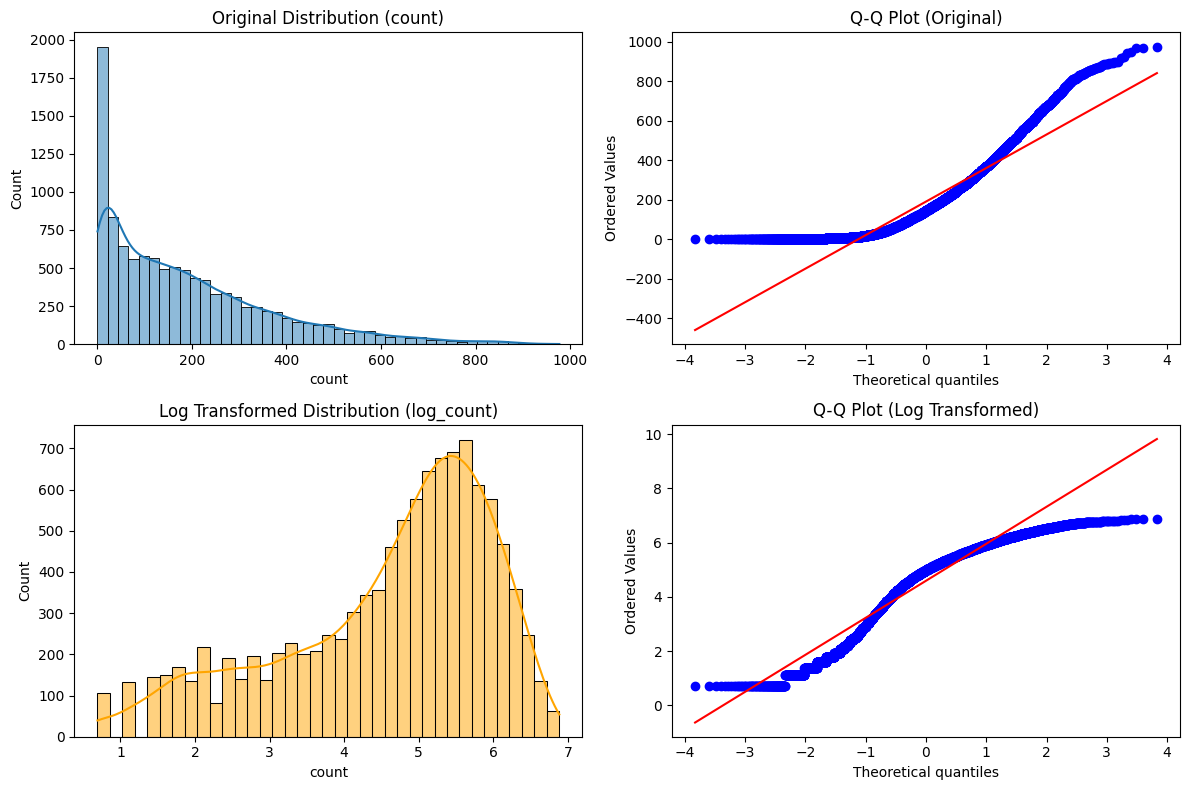

In [ ]:
plt.figure(figsize=(12, 8))

# 3-1. 변환 전 (Original)
plt.subplot(2, 2, 1)
sns.histplot(train['count'], kde=True)
plt.title("Original Distribution (count)")

plt.subplot(2, 2, 2)
stats.probplot(train['count'], dist="norm", plot=plt)
plt.title("Q-Q Plot (Original)")

# 3-2. 변환 후 (Log Transform)
# [주의] 여기서 만든 log_count는 시각화용 임시 변수로만 사용 (train 원본에 넣지 않음)
log_count_temp = np.log1p(train['count'])

plt.subplot(2, 2, 3)
sns.histplot(log_count_temp, kde=True, color='orange')
plt.title("Log Transformed Distribution (log_count)")

plt.subplot(2, 2, 4)
stats.probplot(log_count_temp, dist="norm", plot=plt)
plt.title("Q-Q Plot (Log Transformed)")

plt.tight_layout()
plt.show()

In [ ]:
# 4. 데이터셋 분리 및 정규화
# 4-1. Feature(X)와 Target(y) 정의
# 시각화에서 log_count를 train에 추가하지 않았으므로, drop할 때 'count'만 빼면 됨
X = train.drop(['count'], axis=1).copy()
y = train['count'].values.copy()

# 4-2. 데이터 정규화
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# 4-3. Train / Validation 분리 (시계열: Shuffle=False)
train_size = int(len(X_scaled) * 0.8)

X_train = X_scaled[:train_size]
X_val = X_scaled[train_size:]
y_val_raw = y[train_size:] # 검증용 정답 (공통)

print(f"Train samples: {len(X_train)}, Validation samples: {len(X_val)}")

Train samples: 8708, Validation samples: 2178


In [ ]:
# 5. Case 1: 로그 변환 미적용 학습
print("\n[Case 1] 로그 변환 미적용 학습")
y_train_raw = y[:train_size]

model_raw = MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
model_raw.fit(X_train, y_train_raw)

pred_raw = model_raw.predict(X_val)
pred_raw = np.maximum(pred_raw, 0) # 음수 보정

rmse_raw = np.sqrt(mean_squared_error(y_val_raw, pred_raw))


[Case 1] 로그 변환 미적용 학습


In [ ]:
# 6. Case 2: 로그 변환 적용 학습
# --------------------------------------------------------------------------------
print("\n[Case 2] 로그 변환 적용 학습")

# 학습용 정답 로그 변환 (log1p)
y_train_log = np.log1p(y[:train_size])

model_log = MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
model_log.fit(X_train, y_train_log)

pred_log_scaled = model_log.predict(X_val)

# 복원 (expm1)
pred_restored = np.expm1(pred_log_scaled)
pred_restored = np.maximum(pred_restored, 0)

rmse_log = np.sqrt(mean_squared_error(y_val_raw, pred_restored))


[Case 2] 로그 변환 적용 학습


In [ ]:
# 7. 결과 비교
# --------------------------------------------------------------------------------
print("\n" + "="*50)
print(f"1. 로그 변환 미적용 RMSE : {rmse_raw:.4f}")
print(f"2. 로그 변환 적용 RMSE   : {rmse_log:.4f}")
print(f"-> 성능 개선 효과          : {rmse_raw - rmse_log:.4f}")
print("="*50)


1. 로그 변환 미적용 RMSE : 116.2022
2. 로그 변환 적용 RMSE   : 108.6387
-> 성능 개선 효과          : 7.5635


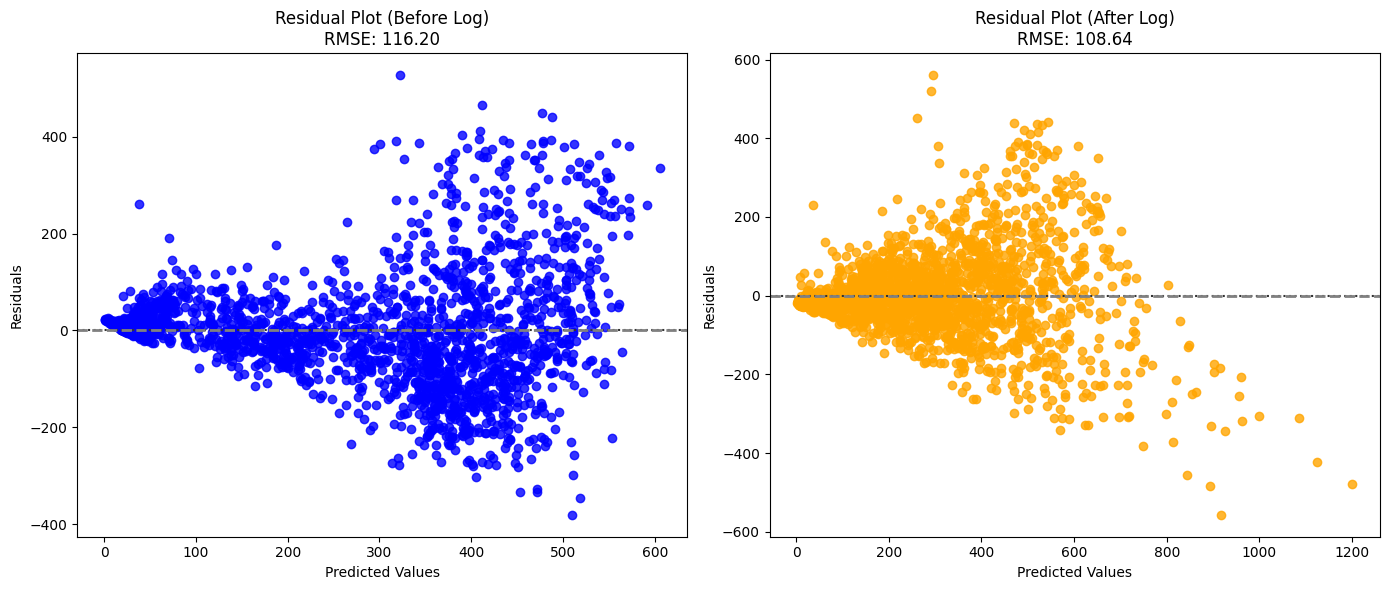

In [ ]:
# 8. 시각화 (Log 변환 전/후 잔차 비교)
# 잔차(Residuals) 계산: 실제값 - 예측값
residuals_raw = y_val_raw - pred_raw          # 로그 변환 전 잔차
residuals_log = y_val_raw - pred_restored     # 로그 변환 후 잔차 (복원된 값 기준)

plt.figure(figsize=(14, 6))

# 1. 로그 변환 이전 (Before Log)
plt.subplot(1, 2, 1)
# lowess=False로 설정하여 에러 방지
sns.residplot(x=pred_raw, y=residuals_raw, lowess=False, color='blue')
plt.axhline(0, color='gray', linestyle='--', linewidth=2) # 기준선 (0)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title(f"Residual Plot (Before Log)\nRMSE: {rmse_raw:.2f}")

# 2. 로그 변환 이후 (After Log)
plt.subplot(1, 2, 2)
# lowess=False로 설정하여 에러 방지
sns.residplot(x=pred_restored, y=residuals_log, lowess=False, color='orange')
plt.axhline(0, color='gray', linestyle='--', linewidth=2) # 기준선 (0)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title(f"Residual Plot (After Log)\nRMSE: {rmse_log:.2f}")

plt.tight_layout()
plt.show()